# Interpolation entre mesures de probabilités
 By Victor Ducros & Georgii Potoshin

# 1. Interpolation(s) entre deux mesures de probabilités


Le premier façons d'interpoler et en variables aleatoires. Donc on pose pour $X_0 \sim \mu_0$, $X_1 \sim \mu_1$ v.a.i. $X_t :=(1-t)X_0+tX_1$.


[T1] Si $X_0$ et $X_1$ admettent des densités $f_0$ et $f_1$, une question naturelle est de calculer la densité de $X_t$.

En passant par la méthode de la fonction muette, on prend $g$ une fonction continue bornée :
$$
\mathbb{E}(g(X_t)) = \mathbb{E}(g(h(X_0, X_1))) \quad \text{où } h(x_0, x_1) = (1 - t)x_0 + t x_1.
$$

Donc, par indépendance de $X_0$ et $X_1$ :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \int_{\mathbb{R}} g((1 - t)x_0 + t x_1) \, f(x_0) \, f(x_1) \, dx_0 \, dx_1.
$$

On effectue le changement de variable : $x = (1 - t)x_0 + t x_1$, en $x_0$ fixé.

On a :
$$
x_1 = \frac{1}{t} \left( x - (1 - t)x_0 \right),
$$
$$
dx = t \, dx_1 \quad \Rightarrow \quad dx_1 = \frac{dx}{t}.
$$

Donc :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} \left( \int_{\mathbb{R}} g(x) \, f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) \frac{dx}{t}.
$$

Ce qui peut s'écrire :
$$
\mathbb{E}(g(X_t)) = \int_{\mathbb{R}} g(x) \left( \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \right) dx.
$$

Donc, par définition, la densité $f_t(x)$ est donnée par :
$$
f_t(x) = \frac{1}{t} \int_{\mathbb{R}} f_0(x_0) \, f_1\left( \frac{x - (1 - t)x_0}{t} \right) \, dx_0 \quad \forall x \in \mathbb{R}.
$$
Cette densité est valable $\forall t \in ]0,1]$. Si $t=0$, on a $f_t=f_0$

[S1] Nous pouvons ainsi visualiser des densités pour differentes lois $X_0$ et $X_1$.

In [1]:
import numpy as np
import matplotlib as mplib
import matplotlib.pyplot as plt
import numpy.random as npr
import scipy.stats as sps
import scipy.integrate as spi
from scipy.stats import norm, uniform
from dataclasses import dataclass

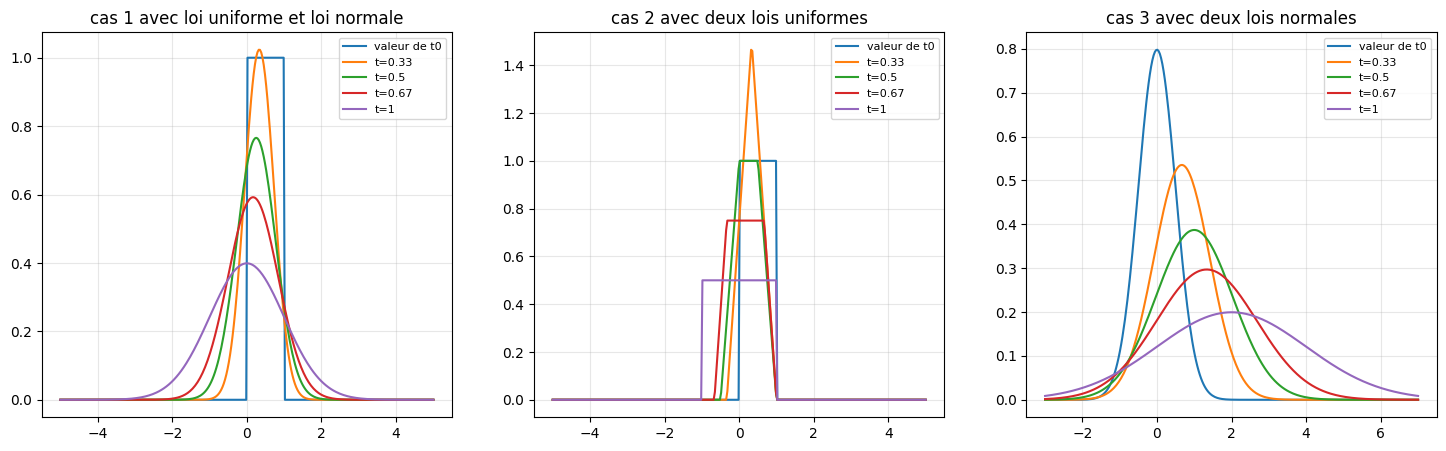

In [8]:
@dataclass
class Context:
    Lx: np.ndarray
    Lt: list[float]
    axes: mplib.axes._axes.Axes
    plt_count: int

    def next_axe(self):
        ax = self.axes[self.plt_count]
        self.plt_count += 1
        return ax

def end_axe(ax, name):
    ax.grid(True, alpha=0.3)
    ax.set_title(name)
    ax.legend(loc="upper right", fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ctx = Context(
    np.linspace(-5,5,300),
    [0,1/3,1/2,2/3,1],
    axes,
    0,
)

def va_inter(ctx, f, g, name, a=0, b=1):
    ax = ctx.next_axe()
    ax.plot(ctx.Lx, f.pdf(ctx.Lx),label="valeur de t"+str(0))
    for t in ctx.Lt[1:]:
        integrale, _ = spi.quad_vec(lambda x0: f.pdf(x0)*g.pdf((ctx.Lx-(1-t)*x0)/t), a, b)
        res = (1/t) * integrale
        ax.plot(ctx.Lx, res, label="t=" + str(round(t, 2)))
    end_axe(ax, name)


va_inter(ctx, uniform, norm, "cas 1 avec loi uniforme et loi normale")
va_inter(ctx, uniform, uniform(loc=-1, scale=2), "cas 2 avec deux lois uniformes")

ctx.Lx = np.linspace(-3,7,300)
va_inter(ctx, norm(loc=0, scale=0.5), norm(loc=2, scale=2), "cas 3 avec deux lois normales", a=-np.inf, b=+np.inf)

plt.show()

[T2] La classe des mesures de Dirac est close par cette opération. En effet,
si on a $f_y, f_x:M\rightarrow\mathbb R$ les v.a. de mesures image $\delta_x, \delta_y$
on a évidament $\mathbb P(tf_y+(1-t)f_x = ty+(1-t)x)=1$, comme $f_y^{-1}[y]\cap
f_x^{-1}[x]$ est de mesure 1, et donc on a pour mesure image $\delta_{tx+(1-t)y}$.

Les mesure uniform sur un interval ne sont pas clos, comme si $X$, $Y$
suivent $U([0,1])$ et qu'on regarde $Z=(X+Y)/2$, une calcule du fonction de densité
donne
\begin{align*}
    \mathbb E f(Z)&=\int f((x+y)/2)\chi_{[0,1]}(x)\chi_{[0,1]}(y)dxdy\\
    &=\int f(z)\chi_{[0,1]}(x)\chi_{[x/2, (x+1)/2]}(z)dx 2dz\\
    &=\int f(z)\left(\int\chi_{[0,1]}(x)\chi_{[x/2, (x+1)/2]}(z)dx\right)2dz\\
    &=\int f(z)\left(\int\chi_{[0,1]}(x)\chi_{[2z-1, 2z]}(x)dx\right)2dz
\end{align*}
donc la fonction de densité $d(z) = 2\int\chi_{[0,1]}(x)\chi_{[2z-1, 2z]}(x)dx$,
et comme on sait que $Z\in[0,1]$, on devrait avoir $d(z)=1$ sur $[0,1]$, mais
déjà $d$ n'est pas constante. Et finalement, les mesures Gaussiennes sont closes
par cette opération et cela fait partie de théorie de notre cours.


Considérons maintenant une seconde façon naturelle d’interpoler, qui consiste simplement à poser
$\eta_t =(1-t)\mu_0+t\mu_1$ pour $t\in[0,1]$.

[T3] bla bla bal

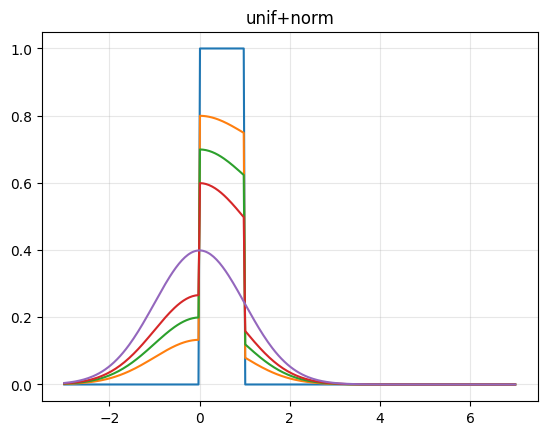

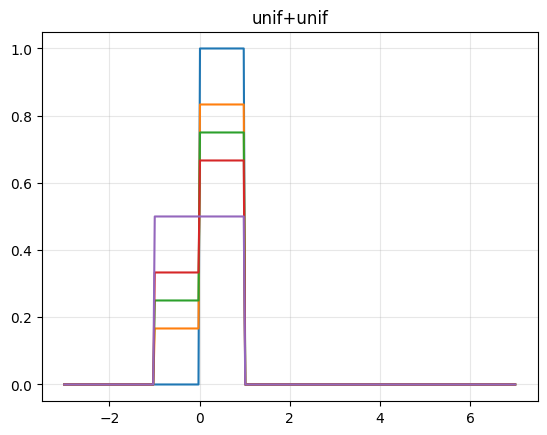

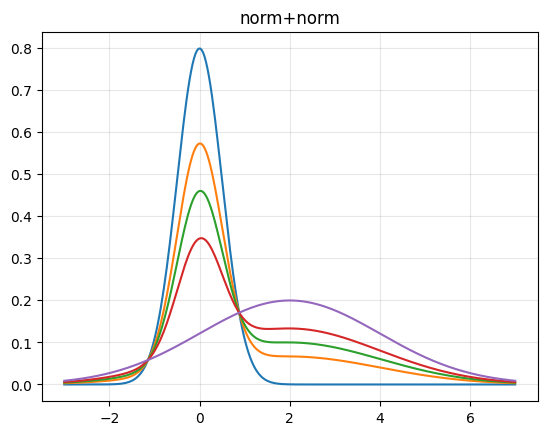

In [4]:
def meas_inter(f, g, name):
    plt.title(name)
    plt.grid(True, alpha=0.3)
    for t in Lt:
        plt.plot(Lx, (1-t)*f.pdf(Lx) + t*g.pdf(Lx), label=f"t = {t}")
    plt.show()

meas_inter(uniform, norm, "unif+norm")
meas_inter(uniform, uniform(loc=-1, scale=2), "unif+unif")
meas_inter(norm(scale=0.5), norm(loc=2, scale=2), "norm+norm")

[T4] bla bla
[S3] 

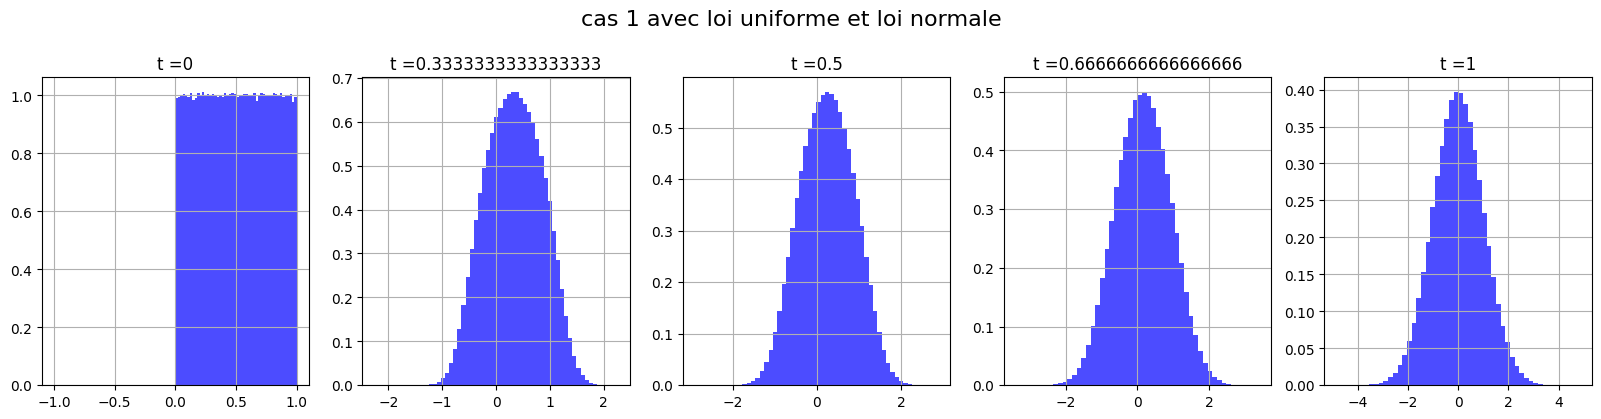

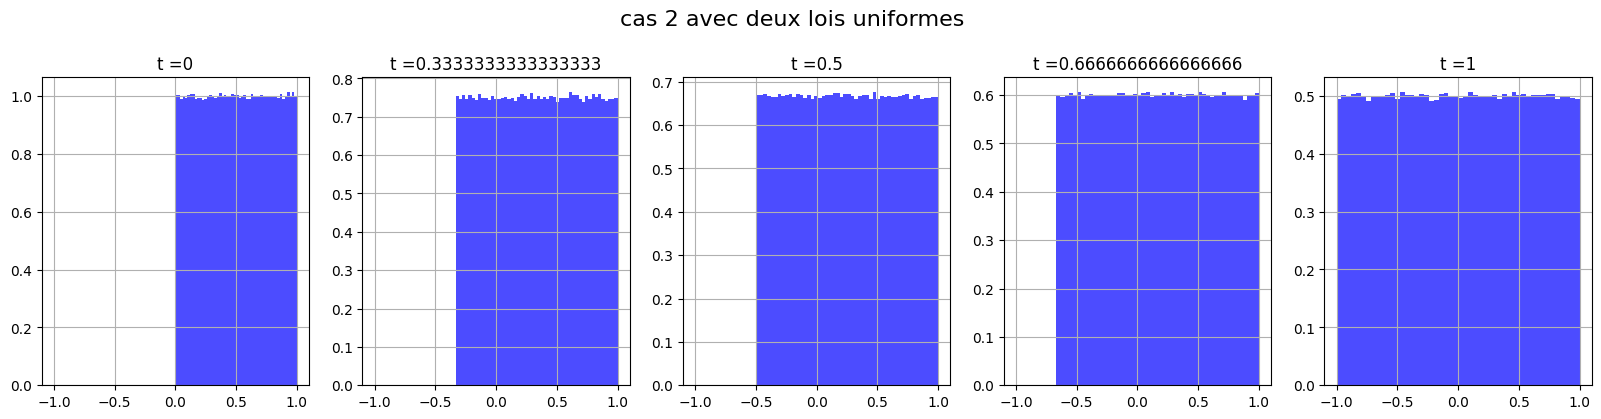

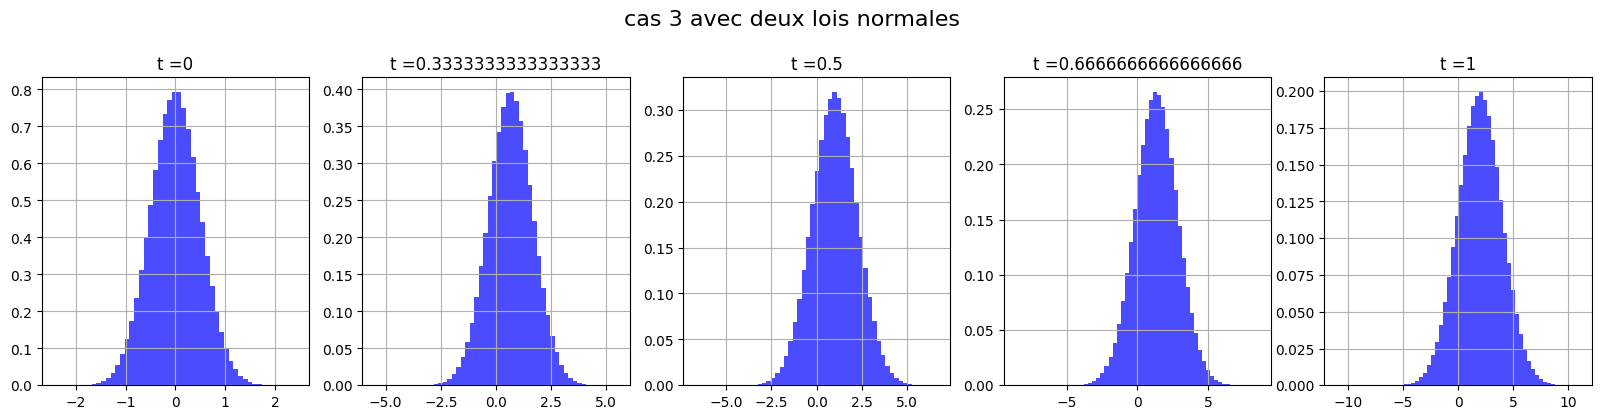

In [6]:
n_echantillon=1000000

def Zt(f0,f1,name):
    fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4))
    fig.suptitle(name, fontsize=16, y=1.05)
    i=0
    for t in Lt:
        U = np.random.uniform(0, 1, n_echantillon)
        Z_t = (1 - t) * f0.ppf(U) + t * f1.ppf(U)
        max_abs = max(abs(np.min(Z_t)), abs(np.max(Z_t)))
        x_min, x_max = -max_abs * 1.1, max_abs * 1.1
        axes[i].hist(Z_t, bins=50, density=True, alpha=0.7, color='blue')
        axes[i].set_xlim(x_min, x_max)
        axes[i].set_title(f"t ="+str(t))
        axes[i].grid(True)
        i+=1

Zt(uniform, norm, "cas 1 avec loi uniforme et loi normale")

Zt(uniform, uniform(loc=-1, scale=2), "cas 2 avec deux lois uniformes")

Zt(norm(loc=0, scale=0.5), norm(loc=2, scale=2), "cas 3 avec deux lois normales")

[T6]
1. Par linéarité $\mathbb E((1-t)X_0+tX_0)= (1-t)\mathbb EX_0 + t\mathbb EX_1$. Pour $η_t = (1−t)µ_0 + tµ_1$ nous avons $\mathbb EX_t=\int xd(t\mu_1+(1-t)\mu_0)=t\int fd\mu_1+(1-t)\int d\mu_0$, car les mesures forme l'éspace dual des fonctions continues à support compact, avec l'action – prendre l'integrale. Et finalement pour $Z_t = (1−t)F^{−1}_0(U)+tF^{−1}_1(U)$ on passe par le même argument que dans le premièr cas, car $F^{-1}_i(U)$ suis le même loi que $X_i$.

2. Suppoosons que $\mu_0=\mu_1$. Qu'est peut on dit d'interpolations? Dans le première type d'interpolation on utilise le même example que dans [T2] est vois que, $\mu_t\neq\mu_0$. Pour deuxiem methode, on a $\mu=(1-t)\mu_0+t\mu_0=\mu_0$. Est dans troisièm example, on a $F_0 = F_1 =: F$ et donc, on a $F^{-1}(U)=X_t\sim X_0$, donc on a la même mesure image.

3. Maitenent on verify que la convergence est coninue en loi. C'est evident pour la deuxiem interpolation, en loi, mais les 2 autres nécéssitent d'attention:

# 2. Distance de Wasserstein